# HSE Incident Data — Python Preparation Layer

This notebook handles metric engineering and data preparation for the Safety Analytics Power BI dashboard.

**What this notebook does:**
- Calculates industry-standard safety rates: TRIR (Total Recordable Incident Rate) and LTIR (Lost Time Injury Rate)
- Engineers key columns: `is_preventable_cost`, `is_lti`, `prevention_score` (JSA + toolbox talk + PPE compliance)
- Builds root cause, facility, activity, and cost summary tables
- Exports enriched dataset (`hse_incident_processed.csv`) for direct use in Power BI

**Pipeline:** Raw CSV → Python metric engineering → `hse_incident_processed.csv` → Power BI dashboard

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('hse_incident_analysis.csv', encoding = 'latin')

In [3]:
df

,incident_id,incident_type,facility,department,activity,root_cause,body_part_affected,personnel_id,age_group,experience_years,...,week_of_year,day_of_week,hour_of_day,month_name,reported_date,investigation_completed_date,total_hours_worked,is_preventable_cost,is_lti,prevention_score
0,INC-2023-00001,Near Miss,Facility B - Maintenance,Workshop,Manual Handling/Lifting,Procedural Non-Compliance,Not Applicable,EMP-0021,36-45,18,...,52,Sunday,2,December,2023-12-31 10:40:48.124751,2024-01-05 10:40:48.124751,2500000.0,0.0,0,1.000000
1,INC-2024-00002,First Aid,Facility A - Production,Production Operations,Chemical Handling,Communication Breakdown,Hand/Finger,EMP-0147,36-45,10,...,3,Tuesday,13,January,2024-01-18 10:40:48.124751,2024-02-01 10:40:48.124751,2500000.0,2404.0,0,1.000000
2,INC-2024-00003,Near Miss,Facility A - Production,Logistics,Vehicle Operations,Poor Housekeeping,Not Applicable,EMP-0014,56+,8,...,4,Wednesday,10,January,2024-01-25 10:40:48.124751,2024-03-08 10:40:48.124751,2500000.0,278.0,0,0.666667
3,INC-2024-00004,First Aid,Facility B - Maintenance,Engineering,Equipment Maintenance,Equipment Failure,Multiple Areas,EMP-0101,46-55,15,...,4,Friday,7,January,2024-01-27 10:40:48.124751,2024-04-13 10:40:48.124751,2500000.0,0.0,0,0.666667
4,INC-2024-00005,First Aid,Facility A - Production,Workshop,Pressure Testing,Inadequate PPE,Not Applicable,EMP-0015,18-25,7,...,5,Thursday,22,February,2024-02-02 10:40:48.124751,2024-02-25 10:40:48.124751,2500000.0,1556.0,0,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,INC-2025-01196,First Aid,Facility B - Maintenance,Engineering,Working at Height,Lack of Training/Competency,Not Applicable,EMP-0039,56+,17,...,42,Thursday,18,October,2025-10-17 10:40:48.124751,2025-11-12 10:40:48.124751,2500000.0,1737.0,0,1.000000
1196,INC-2025-01197,Near Miss,Facility A - Production,Engineering,Confined Space Entry,Poor Housekeeping,Not Applicable,EMP-0158,18-25,10,...,42,Saturday,20,October,2025-10-19 10:40:48.124751,2025-11-09 10:40:48.124751,2500000.0,0.0,0,1.000000
1197,INC-2025-01198,First Aid,Facility A - Production,Maintenance,Manual Handling/Lifting,Communication Breakdown,Back,EMP-0002,56+,29,...,43,Saturday,5,October,2025-10-27 10:40:48.124751,2025-11-14 10:40:48.124751,2500000.0,2179.0,0,0.333333
1198,INC-2025-01199,Near Miss,Facility B - Maintenance,HSE Department,Pressure Testing,Fatigue,Not Applicable,EMP-0019,46-55,0,...,44,Friday,7,October,2025-11-02 10:40:48.124751,2025-12-23 10:40:48.124751,2500000.0,340.0,0,1.000000


# DATA EXPLORATION

In [4]:
df.columns

Index(['incident_id', 'incident_type', 'facility', 'department', 'activity',
       'root_cause', 'body_part_affected', 'personnel_id', 'age_group',
       'experience_years', 'shift', 'severity_level', 'potential_severity',
       'osha_recordable', 'days_away', 'risk_score', 'risk_category',
       'direct_cost_usd', 'indirect_cost_usd', 'productivity_loss_usd',
       'total_incident_cost_usd', 'regulatory_fine_usd',
       'total_cost_with_fines_usd', 'toolbox_talk_conducted', 'jsa_completed',
       'ppe_compliant', 'preventable', 'corrective_action_status',
       'days_to_close', 'investigation_quality_score', 'incident_date', 'year',
       'month', 'quarter', 'week_of_year', 'day_of_week', 'hour_of_day',
       'month_name', 'reported_date', 'investigation_completed_date',
       'total_hours_worked', 'is_preventable_cost', 'is_lti',
       'prevention_score'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   incident_id                   1200 non-null   object 
 1   incident_type                 1200 non-null   object 
 2   facility                      1200 non-null   object 
 3   department                    1200 non-null   object 
 4   activity                      1200 non-null   object 
 5   root_cause                    1200 non-null   object 
 6   body_part_affected            1200 non-null   object 
 7   personnel_id                  1200 non-null   object 
 8   age_group                     1200 non-null   object 
 9   experience_years              1200 non-null   int64  
 10  shift                         1200 non-null   object 
 11  severity_level                1200 non-null   int64  
 12  potential_severity            1200 non-null   int64  
 13  osh

In [6]:
is_unique = df['incident_id'].nunique() == len(df)
is_unique 
# all ids are unique

True

In [7]:
df.isnull().sum()

incident_id                     0
incident_type                   0
facility                        0
department                      0
activity                        0
root_cause                      0
body_part_affected              0
personnel_id                    0
age_group                       0
experience_years                0
shift                           0
severity_level                  0
potential_severity              0
osha_recordable                 0
days_away                       0
risk_score                      0
risk_category                   0
direct_cost_usd                 0
indirect_cost_usd               0
productivity_loss_usd           0
total_incident_cost_usd         0
regulatory_fine_usd             0
total_cost_with_fines_usd       0
toolbox_talk_conducted          0
jsa_completed                   0
ppe_compliant                   0
preventable                     0
corrective_action_status        0
days_to_close                   0
investigation_

In [31]:
df['incident_id'].nunique()

1200

In [32]:
len(df)

TypeError: 'DataFrame' object is not callable

In [8]:
df.describe()

,experience_years,severity_level,potential_severity,osha_recordable,days_away,risk_score,direct_cost_usd,indirect_cost_usd,productivity_loss_usd,total_incident_cost_usd,...,investigation_quality_score,year,month,quarter,week_of_year,hour_of_day,total_hours_worked,is_preventable_cost,is_lti,prevention_score
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,...,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.0,1200.000000,1200.000000,1200.000000
mean,14.574167,2.025000,2.947500,0.280000,2.036667,6.165833,4752.403333,8382.61250,5223.971667,18358.987500,...,7.515000,2024.670000,6.167500,2.396667,25.035833,11.515000,2500000.0,15842.258333,0.050000,0.680833
std,8.685084,1.177085,1.268628,0.449186,7.617875,5.040123,10616.028062,19590.93127,14131.879280,43554.303104,...,1.714319,0.472178,3.141815,1.026418,13.678528,6.891252,0.0,41100.423913,0.218036,0.266922
min,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,70.000000,140.00000,0.000000,218.000000,...,5.000000,2023.000000,1.000000,1.000000,1.000000,0.000000,2500000.0,0.000000,0.000000,0.000000
25%,7.000000,1.000000,2.000000,0.000000,0.000000,3.000000,103.750000,207.00000,0.000000,308.000000,...,6.000000,2024.000000,4.000000,2.000000,14.000000,6.000000,2500000.0,247.000000,0.000000,0.666667
50%,15.000000,2.000000,3.000000,0.000000,0.000000,4.000000,410.500000,791.00000,410.500000,1773.500000,...,8.000000,2025.000000,6.000000,2.000000,24.000000,12.000000,2500000.0,334.000000,0.000000,0.666667
75%,22.000000,3.000000,4.000000,1.000000,0.000000,8.000000,4519.500000,7207.25000,2631.750000,15173.000000,...,9.000000,2025.000000,9.000000,3.000000,35.000000,17.000000,2500000.0,2293.500000,0.000000,1.000000
max,29.000000,5.000000,5.000000,1.000000,57.000000,25.000000,57420.000000,110483.00000,92960.000000,247541.000000,...,10.000000,2025.000000,12.000000,4.000000,52.000000,23.000000,2500000.0,257541.000000,1.000000,1.000000


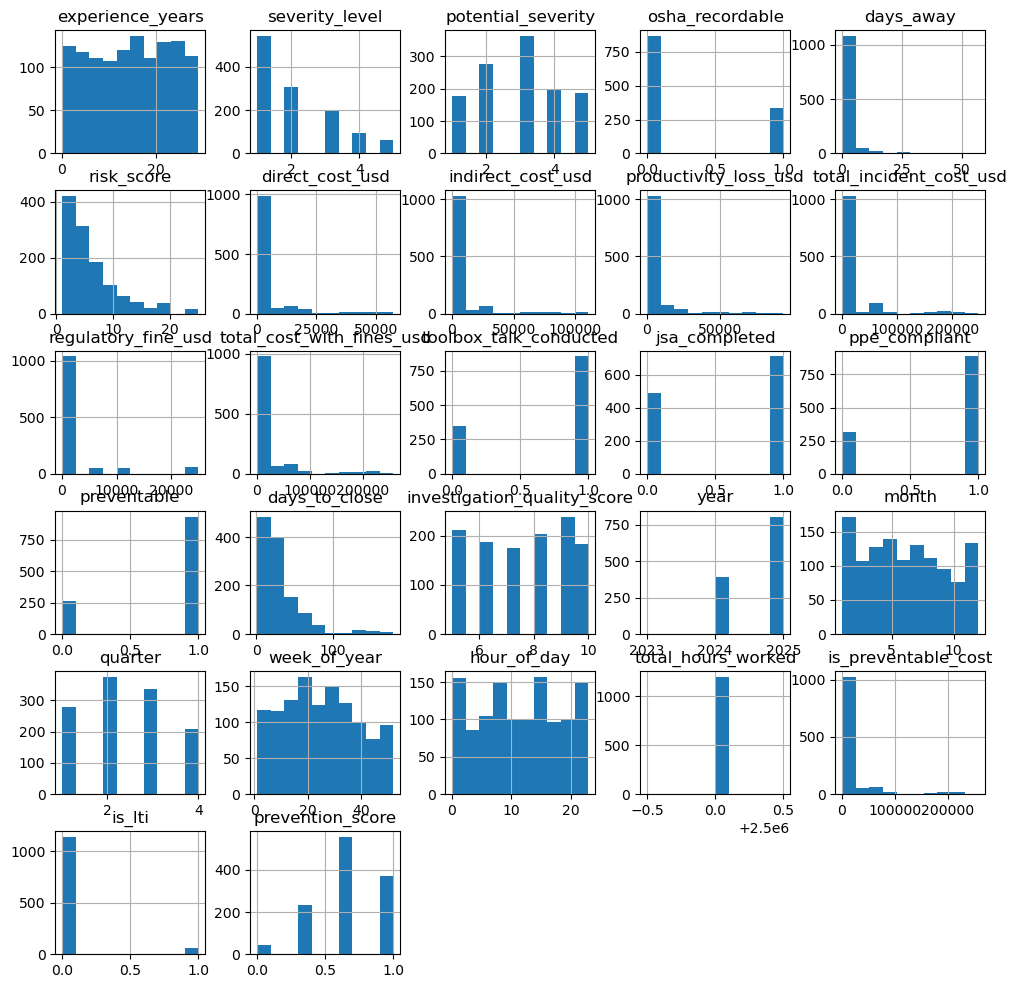

In [9]:
df.hist(figsize=(12,12), bins =10);

In [11]:
# Root Cause Analysis
df.columns

Index(['incident_id', 'incident_type', 'facility', 'department', 'activity',
       'root_cause', 'body_part_affected', 'personnel_id', 'age_group',
       'experience_years', 'shift', 'severity_level', 'potential_severity',
       'osha_recordable', 'days_away', 'risk_score', 'risk_category',
       'direct_cost_usd', 'indirect_cost_usd', 'productivity_loss_usd',
       'total_incident_cost_usd', 'regulatory_fine_usd',
       'total_cost_with_fines_usd', 'toolbox_talk_conducted', 'jsa_completed',
       'ppe_compliant', 'preventable', 'corrective_action_status',
       'days_to_close', 'investigation_quality_score', 'incident_date', 'year',
       'month', 'quarter', 'week_of_year', 'day_of_week', 'hour_of_day',
       'month_name', 'reported_date', 'investigation_completed_date',
       'total_hours_worked', 'is_preventable_cost', 'is_lti',
       'prevention_score'],
      dtype='object')

In [12]:
# 1. Total Recordable Incident Rate(TRIR) & Lost Time Injury Rate(LTIR) Calculation
#  Total hours worked per employee; Industry standard: ~2000 hrs/employee/year
#  Note this is approximated and does not inlude sick leave
N_PERSONNEL = 500
MONITORING_MONTHS = 30 
total_hours = N_PERSONNEL * (MONITORING_MONTHS/12) * 2000
df['total_hours_worked'] = total_hours

# Calculating rates
osha_recordable_count = df['osha_recordable'].sum()
lti_count = len(df[df['incident_type'] == 'Lost Time Injury'])

# Note 200000 is used as a standard when 100 employees(for an organisation) work 40hrs a week in a year.
trir = (osha_recordable_count / total_hours) * 200000
ltir = (lti_count / total_hours) * 200000

print(f"TRIR is {trir:.2f}, meaning that for every 200,000 hours worked, there were approximately {trir:.2f} recordable incidents.")
print(f"LTIR is {ltir:.2f}, meaning that for every 200,000 hours worked, approximately {ltir:.2f} of those incidents resulted in lost time.")


TRIR is 26.88, meaning that for every 200,000 hours worked, there were approximately 26.88 recordable incidents.
LTIR is 4.80, meaning that for every 200,000 hours worked, approximately 4.80 of those incidents resulted in lost time.


In [13]:
# 2. Creating Metrics for visualisation in Power BI

df['is_preventable_cost'] = df['preventable'] * df['total_cost_with_fines_usd']

df['is_lti'] = (df['incident_type'] == 'Lost Time Injury').astype(int)
# df['is_lti'] is lost time due to injury
df['prevention_score'] = (df['jsa_completed'] + df['toolbox_talk_conducted'] + df['ppe_compliant']) / 3
# df['prevention_score'] is how well carrying out the procedures like jsa, toolbox_talk and ppe compliance had effect on the incident reduction.

In [14]:
# Root Cause Analysis

root_cause_summary = df.groupby('root_cause').agg({
    'incident_id': 'count',
    'total_cost_with_fines_usd': 'sum',
    'preventable': 'sum',
    'severity_level': 'mean'
}).rename(columns={
    'incident_id': 'incident_count',
    'total_cost_with_fines_usd': 'total_cost',
    'preventable': 'preventable_count',
    'severity_level': 'avg_severity'
}).reset_index()
root_cause_summary

,root_cause,incident_count,total_cost,preventable_count,avg_severity
0,Communication Breakdown,130,2460418.0,101,1.992308
1,Environmental Factors,123,2780647.0,94,2.081301
2,Equipment Failure,124,3243768.0,95,2.177419
3,Fatigue,104,2801759.0,82,2.134615
4,Inadequate PPE,107,2045783.0,84,2.074766
5,Inadequate Risk Assessment,116,2280818.0,94,1.948276
6,Lack of Training/Competency,106,2565378.0,85,2.216981
7,Poor Housekeeping,139,1849684.0,98,1.848921
8,Procedural Non-Compliance,123,2330964.0,98,1.991870
9,Rushing/Time Pressure,128,2011566.0,105,1.859375


In [15]:
# percentage root cause
root_cause_summary['pct_of_total'] = (root_cause_summary['incident_count'] / len(df)) * 100
root_cause_summary = root_cause_summary.sort_values('incident_count', ascending=False)
root_cause_summary

,root_cause,incident_count,total_cost,preventable_count,avg_severity,pct_of_total
7,Poor Housekeeping,139,1849684.0,98,1.848921,11.583333
0,Communication Breakdown,130,2460418.0,101,1.992308,10.833333
9,Rushing/Time Pressure,128,2011566.0,105,1.859375,10.666667
2,Equipment Failure,124,3243768.0,95,2.177419,10.333333
1,Environmental Factors,123,2780647.0,94,2.081301,10.250000
8,Procedural Non-Compliance,123,2330964.0,98,1.991870,10.250000
5,Inadequate Risk Assessment,116,2280818.0,94,1.948276,9.666667
4,Inadequate PPE,107,2045783.0,84,2.074766,8.916667
6,Lack of Training/Competency,106,2565378.0,85,2.216981,8.833333
3,Fatigue,104,2801759.0,82,2.134615,8.666667


## Time Series Analysis

In [17]:
monthly_trends = df.groupby(['year', 'month', 'month_name']).agg({
    'incident_id': 'count',
    'osha_recordable': 'sum',
    'is_lti': 'sum',
    'total_cost_with_fines_usd': 'sum',
    'preventable': 'sum'
}).rename(columns={
    'incident_id': 'total_incidents',
    'osha_recordable': 'recordable_incidents',
    'is_lti': 'lti_count',
    'total_cost_with_fines_usd': 'total_cost',
    'preventable': 'preventable_incidents'
}).reset_index().sort_values('total_cost', ascending = False)

monthly_trends

,year,month,month_name,total_incidents,recordable_incidents,lti_count,total_cost,preventable_incidents
15,2025,3,March,92,26,9,2676863.0,72
17,2025,5,May,112,31,6,2477127.0,88
16,2025,4,April,115,30,5,1858140.0,90
10,2024,10,October,56,18,6,1768009.0,40
18,2025,6,June,85,26,4,1763453.0,70
13,2025,1,January,76,26,4,1688926.0,59
19,2025,7,July,90,26,3,1583475.0,72
12,2024,12,December,74,25,4,1553277.0,52
11,2024,11,November,57,26,3,1473709.0,45
20,2025,8,August,74,16,3,1439504.0,57


In [18]:
# Total Recordable Incident Rate and Lost Time Injury Rate in each month
hours_per_month = (total_hours / MONITORING_MONTHS)
monthly_trends['trir'] = (monthly_trends['recordable_incidents'] / hours_per_month) * 200000
monthly_trends['ltir'] = (monthly_trends['lti_count'] / hours_per_month) * 200000



In [20]:
prevention_effectiveness = df.groupby(['jsa_completed', 'toolbox_talk_conducted', 'ppe_compliant']).agg({
    'incident_id': 'count',
    'severity_level': 'mean',
    'total_cost_with_fines_usd': 'mean'
}).reset_index()
prevention_effectiveness

,jsa_completed,toolbox_talk_conducted,ppe_compliant,incident_id,severity_level,total_cost_with_fines_usd
0,0,0,0,42,1.833333,13937.880952
1,0,0,1,83,2.048193,24298.120482
2,0,1,0,93,1.838710,15328.569892
3,0,1,1,271,2.154982,25473.815498
4,1,0,0,58,1.982759,14066.775862
5,1,0,1,163,1.957055,18267.521472
6,1,1,0,121,1.900826,11904.785124
7,1,1,1,369,2.070461,22237.753388


In [22]:
facility_dept_summary = df.groupby(['facility', 'department']).agg({
    'incident_id': 'count',
    'osha_recordable': 'sum',
    'total_cost_with_fines_usd': 'sum',
    'preventable': 'sum'
}).reset_index()
facility_dept_summary

,facility,department,incident_id,osha_recordable,total_cost_with_fines_usd,preventable
0,Facility A - Production,Engineering,110,24,1986047.0,85
1,Facility A - Production,HSE Department,116,32,2762564.0,83
2,Facility A - Production,Logistics,108,29,2181114.0,89
3,Facility A - Production,Maintenance,96,28,2406442.0,73
4,Facility A - Production,Production Operations,92,28,1776875.0,71
5,Facility A - Production,Workshop,81,19,1353494.0,68
6,Facility B - Maintenance,Engineering,97,23,1298820.0,77
7,Facility B - Maintenance,HSE Department,109,35,2096869.0,79
8,Facility B - Maintenance,Logistics,95,35,2470315.0,78
9,Facility B - Maintenance,Maintenance,95,34,2409556.0,77


In [23]:
# Shows activities that result in different incidents their incident_count, severity and average_risk_scores
activity_summary = df.groupby('activity').agg({
    'incident_id': 'count',
    'severity_level': 'mean',
    'risk_score': 'mean',
    'total_cost_with_fines_usd': 'sum'
}).rename(columns={
    'incident_id': 'incident_count',
    'severity_level': 'avg_severity',
    'risk_score': 'avg_risk_score',
    'total_cost_with_fines_usd': 'total_cost'
}).reset_index()
activity_summary

,activity,incident_count,avg_severity,avg_risk_score,total_cost
0,Chemical Handling,118,1.974576,6.127119,2645432.0
1,Confined Space Entry,137,1.802920,5.357664,2052129.0
2,Equipment Maintenance,123,2.000000,5.756098,2389363.0
3,Hot Work (Welding/Cutting),119,2.033613,5.504202,2028931.0
4,Housekeeping,123,1.951220,5.707317,2001725.0
5,Manual Handling/Lifting,122,2.016393,6.778689,2628750.0
6,Pressure Testing,113,2.132743,6.539823,2604761.0
7,Routine Operations,110,2.163636,7.190909,2346394.0
8,Vehicle Operations,108,2.166667,6.592593,3375565.0
9,Working at Height,127,2.070866,6.362205,2297735.0


In [24]:
cost_summary = df.groupby('incident_type').agg({
    'incident_id': 'count',
    'direct_cost_usd': 'sum',
    'indirect_cost_usd': 'sum',
    'productivity_loss_usd': 'sum',
    'regulatory_fine_usd': 'sum',
    'total_cost_with_fines_usd': 'sum',
    'preventable': 'sum'
}).reset_index()
cost_summary

,incident_type,incident_id,direct_cost_usd,indirect_cost_usd,productivity_loss_usd,regulatory_fine_usd,total_cost_with_fines_usd,preventable
0,Environmental Spill,18,363475.0,723245.0,269190.0,0,1355910.0,15
1,Equipment Damage,6,61508.0,55111.0,27111.0,0,143730.0,4
2,First Aid,300,149483.0,296185.0,150900.0,0,596568.0,225
3,Lost Time Injury,60,2721773.0,5032994.0,3619699.0,435000,11809466.0,46
4,Medical Treatment,180,897614.0,1430164.0,538621.0,1315000,4181399.0,141
5,Near Miss,540,53931.0,108568.0,0.0,0,162499.0,428
6,Restricted Work,96,1455100.0,2412868.0,1663245.0,590000,6121213.0,77


In [25]:
preventable_cost = df[df['preventable'] == 1].groupby('incident_type')['total_cost_with_fines_usd'].sum().reset_index(name='preventable_cost')
preventable_cost

,incident_type,preventable_cost
0,Environmental Spill,1152228.0
1,Equipment Damage,95555.0
2,First Aid,444747.0
3,Lost Time Injury,9089669.0
4,Medical Treatment,3244335.0
5,Near Miss,128607.0
6,Restricted Work,4855569.0


In [26]:
cost_summary = cost_summary.merge(preventable_cost, on='incident_type', how='left')
cost_summary['preventable_cost'] = cost_summary['preventable_cost'].fillna(0)
cost_summary

,incident_type,incident_id,direct_cost_usd,indirect_cost_usd,productivity_loss_usd,regulatory_fine_usd,total_cost_with_fines_usd,preventable,preventable_cost
0,Environmental Spill,18,363475.0,723245.0,269190.0,0,1355910.0,15,1152228.0
1,Equipment Damage,6,61508.0,55111.0,27111.0,0,143730.0,4,95555.0
2,First Aid,300,149483.0,296185.0,150900.0,0,596568.0,225,444747.0
3,Lost Time Injury,60,2721773.0,5032994.0,3619699.0,435000,11809466.0,46,9089669.0
4,Medical Treatment,180,897614.0,1430164.0,538621.0,1315000,4181399.0,141,3244335.0
5,Near Miss,540,53931.0,108568.0,0.0,0,162499.0,428,128607.0
6,Restricted Work,96,1455100.0,2412868.0,1663245.0,590000,6121213.0,77,4855569.0


In [27]:
df

,incident_id,incident_type,facility,department,activity,root_cause,body_part_affected,personnel_id,age_group,experience_years,...,week_of_year,day_of_week,hour_of_day,month_name,reported_date,investigation_completed_date,total_hours_worked,is_preventable_cost,is_lti,prevention_score
0,INC-2023-00001,Near Miss,Facility B - Maintenance,Workshop,Manual Handling/Lifting,Procedural Non-Compliance,Not Applicable,EMP-0021,36-45,18,...,52,Sunday,2,December,2023-12-31 10:40:48.124751,2024-01-05 10:40:48.124751,2500000.0,0.0,0,1.000000
1,INC-2024-00002,First Aid,Facility A - Production,Production Operations,Chemical Handling,Communication Breakdown,Hand/Finger,EMP-0147,36-45,10,...,3,Tuesday,13,January,2024-01-18 10:40:48.124751,2024-02-01 10:40:48.124751,2500000.0,2404.0,0,1.000000
2,INC-2024-00003,Near Miss,Facility A - Production,Logistics,Vehicle Operations,Poor Housekeeping,Not Applicable,EMP-0014,56+,8,...,4,Wednesday,10,January,2024-01-25 10:40:48.124751,2024-03-08 10:40:48.124751,2500000.0,278.0,0,0.666667
3,INC-2024-00004,First Aid,Facility B - Maintenance,Engineering,Equipment Maintenance,Equipment Failure,Multiple Areas,EMP-0101,46-55,15,...,4,Friday,7,January,2024-01-27 10:40:48.124751,2024-04-13 10:40:48.124751,2500000.0,0.0,0,0.666667
4,INC-2024-00005,First Aid,Facility A - Production,Workshop,Pressure Testing,Inadequate PPE,Not Applicable,EMP-0015,18-25,7,...,5,Thursday,22,February,2024-02-02 10:40:48.124751,2024-02-25 10:40:48.124751,2500000.0,1556.0,0,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,INC-2025-01196,First Aid,Facility B - Maintenance,Engineering,Working at Height,Lack of Training/Competency,Not Applicable,EMP-0039,56+,17,...,42,Thursday,18,October,2025-10-17 10:40:48.124751,2025-11-12 10:40:48.124751,2500000.0,1737.0,0,1.000000
1196,INC-2025-01197,Near Miss,Facility A - Production,Engineering,Confined Space Entry,Poor Housekeeping,Not Applicable,EMP-0158,18-25,10,...,42,Saturday,20,October,2025-10-19 10:40:48.124751,2025-11-09 10:40:48.124751,2500000.0,0.0,0,1.000000
1197,INC-2025-01198,First Aid,Facility A - Production,Maintenance,Manual Handling/Lifting,Communication Breakdown,Back,EMP-0002,56+,29,...,43,Saturday,5,October,2025-10-27 10:40:48.124751,2025-11-14 10:40:48.124751,2500000.0,2179.0,0,0.333333
1198,INC-2025-01199,Near Miss,Facility B - Maintenance,HSE Department,Pressure Testing,Fatigue,Not Applicable,EMP-0019,46-55,0,...,44,Friday,7,October,2025-11-02 10:40:48.124751,2025-12-23 10:40:48.124751,2500000.0,340.0,0,1.000000


In [28]:
key_metrics = {
    'total_incidents': len(df),
    'trir': round(trir, 2),
    'ltir': round(ltir, 2),
    'total_cost': df['total_cost_with_fines_usd'].sum(),
    'preventable_incidents': df['preventable'].sum(),
    'preventable_cost': preventable_cost,
    'avg_days_to_close': round(df['days_to_close'].mean(), 1),
    'overdue_actions': len(df[df['corrective_action_status'] == 'Overdue']),
    'top_root_cause': root_cause_summary.iloc[0]['root_cause'],
    'top_root_cause_count': int(root_cause_summary.iloc[0]['incident_count']),
    'highest_risk_activity': activity_summary.iloc[0]['activity']
}

In [30]:
df.columns

Index(['incident_id', 'incident_type', 'facility', 'department', 'activity',
       'root_cause', 'body_part_affected', 'personnel_id', 'age_group',
       'experience_years', 'shift', 'severity_level', 'potential_severity',
       'osha_recordable', 'days_away', 'risk_score', 'risk_category',
       'direct_cost_usd', 'indirect_cost_usd', 'productivity_loss_usd',
       'total_incident_cost_usd', 'regulatory_fine_usd',
       'total_cost_with_fines_usd', 'toolbox_talk_conducted', 'jsa_completed',
       'ppe_compliant', 'preventable', 'corrective_action_status',
       'days_to_close', 'investigation_quality_score', 'incident_date', 'year',
       'month', 'quarter', 'week_of_year', 'day_of_week', 'hour_of_day',
       'month_name', 'reported_date', 'investigation_completed_date',
       'total_hours_worked', 'is_preventable_cost', 'is_lti',
       'prevention_score'],
      dtype='object')

In [29]:
df.to_csv('hse_incident_processed.csv', index=False)

# Summary tables (smaller, faster in Power BI)
root_cause_summary.to_csv('summary_root_causes.csv', index=False)
activity_summary.to_csv('summary_activities.csv', index=False)
monthly_trends.to_csv('summary_monthly_trends.csv', index=False)
prevention_effectiveness.to_csv('summary_prevention.csv', index=False)
facility_dept_summary.to_csv('summary_facility_dept.csv', index=False)
cost_summary.to_csv('summary_costs.csv', index=False)
